In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import numpy as np
import pandas as pd
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Conv1D, Flatten, MaxPooling1D, Concatenate, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix

In [2]:
%matplotlib inline

In [3]:
value_df = 10000
star_check = pd.read_csv("./Datasets/final_dataset.csv")
star_check = star_check.drop(['tid'],axis=1)
star_check_y = star_check[['confirmed_planet']]
star_check = star_check.reset_index().drop('index',axis=1)
star_check = star_check.apply(lambda row: row.fillna(0), axis=1)

In [4]:
avg_val = int(star_check.value_counts(star_check['confirmed_planet']).mean())
balanced_star_check = pd.DataFrame()
class_counts = star_check['confirmed_planet'].value_counts()
for i in range(0,2):
    if class_counts.loc[class_counts.index == i].iloc[0] > avg_val:
        balanced_star_check = pd.concat([balanced_star_check, star_check[star_check['confirmed_planet'] == i].sample(avg_val)])
    else:
        balanced_star_check = pd.concat([balanced_star_check, star_check[star_check['confirmed_planet'] == i].sample(avg_val, replace=True)])
star_check = balanced_star_check.copy()

In [5]:
scaler = MinMaxScaler()
star_check[['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx']] = scaler.fit_transform(star_check[['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx']])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(star_check.drop('confirmed_planet',axis=1),star_check[['confirmed_planet']], test_size=0.1, random_state=42)

In [7]:
X_train_flux = X_train.drop(['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx'],axis=1)
X_train_params = X_train[['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx']]
X_test_flux = X_test.drop(['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx'],axis=1)
X_test_params = X_test[['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx']]

In [8]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(10000,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dropout(0.75),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/Users/nasvinnabeel/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
2024-04-11 19:00:55.157648: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-04-11 19:00:55.159352: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2024-04-11 19:00:55.159827: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2024-04-11 19:00:55.161058: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-04-11 19:00:55.162635: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/re

In [9]:
# model.fit(X_train_flux, y_train, epochs=30, batch_size=32, validation_data=(X_test_flux, y_test))

In [6]:
for i in range(1):
    print(i)

0


In [1]:
from astroquery.mast import Catalogs
Catalogs.query_criteria(catalog='Tic', ID=139086171)

ConnectionError: HTTPSConnectionPool(host='mast.stsci.edu', port=443): Max retries exceeded with url: /portal/Mashup/Mashup.asmx/columnsconfig (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x127e57090>: Failed to establish a new connection: [Errno 51] Network is unreachable'))

In [1]:
import csv

with open('./Datasets/exoplanet_star_normal_flux.csv', 'r') as f:
    data = f.readlines()

In [3]:
data_sizes = [ len(i)-1 for i in data[1:]]

In [5]:
max(data_sizes)

1574525

In [6]:
min(data_sizes)

11159

In [7]:
max(data_sizes)/min(data_sizes)

141.0991128237297

In [8]:
import math

num1 = 1574525
num2 = 11159

# Find the GCD of num1 and num2
gcd = math.gcd(num1, num2)

# Divide num1 and num2 by the GCD to simplify the proportion
simplified_num1 = num1 // gcd
simplified_num2 = num2 // gcd

print(f"Simplified proportion is {simplified_num1}:{simplified_num2}")

Simplified proportion is 1574525:11159


<Axes: xlabel='Time [JD]', ylabel='Flux'>

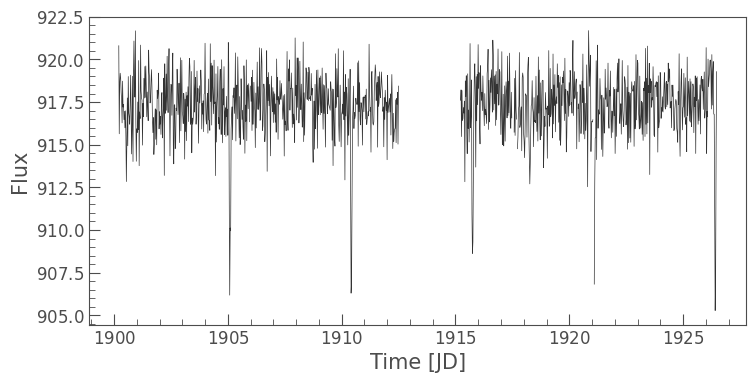

In [27]:
import astropy.io.fits as fits
import lightkurve as lk
from astropy.time import Time
import numpy as np

# Read the FITS file
hdulist = fits.open('test_fits.fits')
data = hdulist[1].data

# Extract relevant data
time = data['TIME']
flux = data['PDCSAP_FLUX']
error = data['PDCSAP_FLUX_ERR']

finite_indices = np.isfinite(time)
clean_time = time[finite_indices]

lc = lk.LightCurve(time=Time(clean_time, format='jd'), flux=flux[finite_indices], flux_err=error[finite_indices])

# Analyze and visualize the light curve
lc.plot()


In [28]:
def process_file(file):
    try:
        with fits.open(file) as hdulist:
            time = hdulist[1].data['TIME'].astype(float)
            flux = hdulist[1].data['PDCSAP_FLUX'].astype(float)
            error = hdulist[1].data['PDCSAP_FLUX_ERR'].astype(float)

            # Only keep finite values for processing
            finite_mask = np.isfinite(time) & np.isfinite(flux) & np.isfinite(error)
            time, flux, error = time[finite_mask], flux[finite_mask], error[finite_mask]

            lc = lk.LightCurve(time=Time(time, format='jd'), flux=flux, flux_err=error)

            # Simple example of folding and plotting
            period = 10  # This should be determined via analysis such as BLS
            folded_lc = lc.fold(period=period)
            plt.figure()
            plt.plot(folded_lc.time.value, folded_lc.flux, 'k.')
            plt.xlabel('Phase')
            plt.ylabel('Flux')
            plt.title('Folded Light Curve')
            plt.savefig(general_plot_path)
            plt.close()
        
            stitched_lc = lc.stitch() 

            min_period = 1
            max_period = 1000
            num_periods = 10000
            period_time = np.logspace(np.log10(min_period), np.log10(max_period), num_periods)
            bls_periodogram = stitched_lc.to_periodogram(method='bls', period=period_time)
            planet_period = bls_periodogram.period_at_max_power
            planet_t0 = bls_periodogram.transit_time_at_max_power
            folded_light_curve = stitched_lc.fold(period=planet_period, epoch_time=planet_t0)
            print("trial")
            flatten_lc, trend_lc = flatten(folded_light_curve.time.value, folded_light_curve.flux, method='biweight', return_trend=True)
            print("trial2")
            light = pd.DataFrame({'Time':folded_light_curve.time.value,'Flux':flatten_lc}).dropna()
            print("okay?")
            flux_series = pd.Series([i[0] for i in light[['Flux']].to_numpy()], index=[i[0] for i in light[['Time']].to_numpy()])
            print("okay?")
            decompose_result_mult = seasonal_decompose(flux_series, model="additive", period=int(planet_period.value))
            print("okay?")
            trend = TimeSeriesResampler(sz=10000).fit_transform(np.array(decompose_result_mult.trend))[0]
            
            status = 0
            model = input_flux = Input(shape=(10000,1))
            x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_flux)
            x = MaxPooling1D(pool_size=2)(x)
            x = Conv1D(filters=64, kernel_size=5, activation='relu')(x)
            x = MaxPooling1D(pool_size=2)(x)
            x = Conv1D(filters=64, kernel_size=5, activation='relu')(x)
            x = MaxPooling1D(pool_size=2)(x)
            x = Flatten()(x)
            x = Dropout(0.75)(x)
            model_flux = Model(inputs=input_flux, outputs=x)

            input_params = Input(shape=(11,))
            y = Dense(128, activation='relu')(input_params)
            model_params = Model(inputs=input_params, outputs=y)

            combined = Concatenate()([model_flux.output, model_params.output])
            z = Dropout(0.5)(combined)
            z = Dense(128, activation='relu')(z)
            final_output = Dense(1, activation='sigmoid')(z)

            model = Model(inputs=[model_flux.input, model_params.input], outputs=final_output)
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            model.load_weights('../../Models/model_weights_v5.h5')
            
            catalog_data = Catalogs.query_criteria(catalog="Tic", ID=int(identifier[4:]))[['Teff','logg','MH','rad','mass','rho','lum','Tmag','ra','dec','plx']].to_pandas().fillna(0)
            
            scaler = MinMaxScaler()
            catalog_data = scaler.fit_transform(catalog_data)
        
            status_val = model.predict([trend.reshape(1, 10000, 1), catalog_data.reshape(1, -1)], verbose=0)
            if status_val == 1:
                status = "Potential Exoplanet Candidate"
            else:
                status = "No Exoplanet Transit Signals Detected"
            
            plt.figure(figsize=(9.10, 2.15))
            plt.plot(range(10000), trend, color="#FF4C29")
            plt.gcf().set_facecolor('#202123')  # Set background color of the figure
            plt.grid(False)
            plt.axis('off')
            plt.savefig(trend_plot_path)
            plt.close()

            return {
            'general_plot_url': f'/api/images/custom_general_plot.png',
            'trend_plot_url': f'/api/images/custom_trend_plot.png',
            'status': status
            }
    except Exception as e:
        return {"error": str(e)}, 500

/Users/nasvinnabeel/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 1121 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/Users/nasvinnabeel/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


({'error': "name 'general_plot_path' is not defined"}, 500)

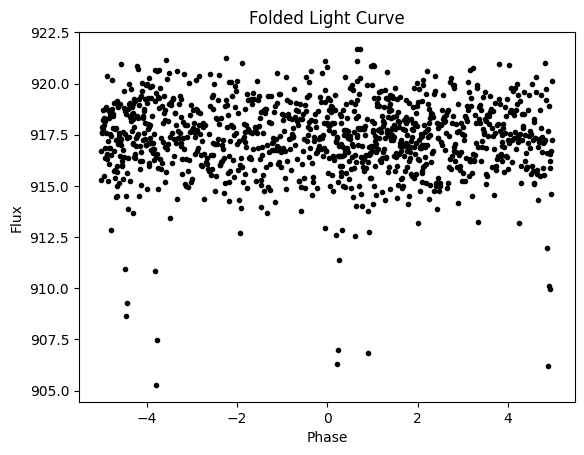

In [29]:
process_file('test_fits.fits')